Google Colab Setup
This section handles:
1. Mounting Google Drive
2. Installing required packages
3. Setting up project paths

In [3]:
# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("✓ Running in Google Colab")
except:
    IN_COLAB = False
    print("✓ Running locally")

# %%
# Mount Google Drive (only in Colab)
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Google Drive mounted at /content/drive")

    # Set base path to your Google Drive
    # UPDATE THIS PATH to match your Google Drive folder structure
    GDRIVE_BASE = '/content/drive/MyDrive/Electric Sheep/Beliz - EDA'

    print(f"✓ Project base set to: {GDRIVE_BASE}")
else:
    # If running locally, use current directory
    GDRIVE_BASE = '.'
    print("✓ Using local directory")

# %%
# Install required packages
print("\nInstalling required packages...")

# Core packages
!pip install -q librosa soundfile

# Optional but recommended
!pip install -q librosa[display]  # For visualization support

print("✓ All packages installed")

# %%
# Import libraries and verify installation
import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')  # Use default for better Colab compatibility
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("\n✓ All libraries imported successfully")
print(f"Librosa version: {librosa.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

# %%
# Create project directory structure in Google Drive
from pathlib import Path

# Define project structure - ALL paths now in Google Drive
PROJECT_ROOT = Path(GDRIVE_BASE)
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

# Create directories in Google Drive
print("\nCreating project directories in Google Drive...")
for directory in [DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR,
                  FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
    print(f"✓ Created: {directory}")

print("\nProject structure ready")

# %%
# Path to your dataset.zip in Google Drive
# UPDATE THIS PATH to match where you uploaded dataset.zip
ZIP_PATH = PROJECT_ROOT / "dataset.zip"

print(f"\nLooking for dataset at: {ZIP_PATH}")

if ZIP_PATH.exists():
    print(f"✓ Found dataset.zip ({ZIP_PATH.stat().st_size / 1024 / 1024:.2f} MB)")
else:
    print(f"Dataset not found!")
    print(f"\nPlease upload dataset.zip to Google Drive and update ZIP_PATH variable")
    print(f"Current expected location: {ZIP_PATH}")

    # Show current Google Drive contents to help user
    print(f"\nContents of {PROJECT_ROOT}:")
    if PROJECT_ROOT.exists():
        for item in PROJECT_ROOT.iterdir():
            print(f"  - {item.name}")

✓ Running in Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted at /content/drive
✓ Project base set to: /content/drive/MyDrive/Electric Sheep/Beliz - EDA

Installing required packages...
✓ All packages installed

✓ All libraries imported successfully
Librosa version: 0.11.0
NumPy version: 2.0.2
Pandas version: 2.2.2

Creating project directories in Google Drive...
✓ Created: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/data
✓ Created: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/data/raw
✓ Created: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/data/processed
✓ Created: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/figures
✓ Created: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/models

📁 Project structure ready!

Looking for dataset at: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/dataset.zip
✓ Found dataset.zip (8.45 MB)


# CAT MEOWS DATASET - EXPLORATORY DATA ANALYSIS AND PREPROCESSING

In [ ]:
# Import libraries
import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All libraries imported successfully")
print(f"Librosa version: {librosa.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

In [4]:
# Extract dataset
if ZIP_PATH.exists():
    print(f"Found dataset at: {ZIP_PATH}")
    print("Extracting files...")

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(RAW_DATA_DIR)

    print("✓ Dataset extracted successfully")
else:
    print(f"Dataset not found at {ZIP_PATH}")
    print("Please update ZIP_PATH variable to point to your dataset.zip file")

# %%
# List all WAV files
wav_files = list(RAW_DATA_DIR.glob("**/*.wav"))
print(f"\n📊 Dataset Summary:")
print(f"Total WAV files found: {len(wav_files)}")
print(f"\nFirst 5 files:")
for f in wav_files[:5]:
    print(f"  - {f.name}")

# ### Filename Pattern: `C_NNNNN_BB_SS_OOOOO_RXX.wav`
# - **C**: Context (B=Brushing, F=Food, I=Isolation)
# - **NNNNN**: Cat unique ID
# - **BB**: Breed (MC=Maine Coon, EU=European Shorthair)
# - **SS**: Sex (FI=Female intact, FN=Female neutered, MI=Male intact, MN=Male neutered)
# - **OOOOO**: Owner unique ID
# - **R**: Recording session (1, 2, or 3)
# - **XX**: Vocalization counter (01-99)

def parse_filename(filename):
    """
    Parse cat meow filename to extract metadata.

    Args:
        filename (str): Filename following pattern C_NNNNN_BB_SS_OOOOO_RXX.wav

    Returns:
        dict: Parsed metadata or None if parsing fails
    """
    # Remove .wav extension
    name = filename.replace('.wav', '')

    # Split by underscore
    parts = name.split('_')

    # Check if we have expected number of parts
    if len(parts) != 6:
        print(f"Warning: Unexpected filename format: {filename}")
        return None

    try:
        # Extract components
        context = parts[0]
        cat_id = parts[1]
        breed = parts[2]
        sex = parts[3]
        owner_id = parts[4]

        # Session and vocalization number are combined (e.g., "101")
        session_voc = parts[5]
        session = session_voc[0]  # First character
        voc_num = session_voc[1:]  # Remaining characters

        # Create distress label
        # I (Isolation) = Distress (1)
        # B (Brushing) and F (Food) = Normal (0)
        distress_label = 1 if context == 'I' else 0

        return {
            'filename': filename,
            'context': context,
            'cat_id': cat_id,
            'breed': breed,
            'sex': sex,
            'owner_id': owner_id,
            'session': session,
            'vocalization_num': voc_num,
            'distress_label': distress_label
        }
    except Exception as e:
        print(f"Error parsing {filename}: {e}")
        return None

# %%
# Parse all filenames
print("Parsing filenames...")
metadata_list = []

for wav_file in tqdm(wav_files, desc="Processing files"):
    parsed = parse_filename(wav_file.name)
    if parsed:
        # Add full file path
        parsed['file_path'] = str(wav_file)
        metadata_list.append(parsed)

# Create DataFrame
df_metadata = pd.DataFrame(metadata_list)

print(f"\n✓ Parsed {len(df_metadata)} files successfully")
print(f"\nDataFrame shape: {df_metadata.shape}")
print(f"\nFirst few rows:")
display(df_metadata.head(10))

# Save metadata
metadata_csv_path = DATA_DIR / "metadata.csv"
df_metadata.to_csv(metadata_csv_path, index=False)
print(f"✓ Metadata saved to: {metadata_csv_path}")

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print(f"\n Total Recordings: {len(df_metadata)}")

print(f"\n Context Distribution:")
context_counts = df_metadata['context'].value_counts().sort_index()
for ctx, count in context_counts.items():
    context_name = {'B': 'Brushing', 'F': 'Food waiting', 'I': 'Isolation'}[ctx]
    print(f"  {ctx} ({context_name:15s}): {count:3d} recordings ({count/len(df_metadata)*100:.1f}%)")

print(f"\n  Distress Label Distribution:")
label_counts = df_metadata['distress_label'].value_counts().sort_index()
for label, count in label_counts.items():
    label_name = {0: 'Normal', 1: 'Distress'}[label]
    print(f"  {label} ({label_name:8s}): {count:3d} recordings ({count/len(df_metadata)*100:.1f}%)")

print(f"\n Unique Cats: {df_metadata['cat_id'].nunique()}")
print(f" Unique Owners: {df_metadata['owner_id'].nunique()}")

print(f"\n Breed Distribution:")
breed_counts = df_metadata['breed'].value_counts()
for breed, count in breed_counts.items():
    breed_name = {'MC': 'Maine Coon', 'EU': 'European Shorthair'}[breed]
    print(f"  {breed} ({breed_name:20s}): {count:3d} recordings")

print(f"\n  Sex Distribution:")
sex_counts = df_metadata['sex'].value_counts()
sex_mapping = {'FI': 'Female intact', 'FN': 'Female neutered',
               'MI': 'Male intact', 'MN': 'Male neutered'}
for sex, count in sex_counts.items():
    print(f"  {sex} ({sex_mapping.get(sex, sex):15s}): {count:3d} recordings")

print(f"\n Recording Sessions:")
session_counts = df_metadata['session'].value_counts().sort_index()
for session, count in session_counts.items():
    print(f"  Session {session}: {count:3d} recordings")


Found dataset at: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/dataset.zip
Extracting files...
✓ Dataset extracted successfully

📊 Dataset Summary:
Total WAV files found: 440

First 5 files:
  - F_MAG01_EU_FN_FED01_106.wav
  - I_NUL01_MC_MI_SIM01_304.wav
  - I_MEG01_MC_FI_SIM01_304.wav
  - B_CAN01_EU_FN_GIA01_205.wav
  - F_MAG01_EU_FN_FED01_304.wav
Parsing filenames...


Processing files: 100%|██████████| 440/440 [00:00<00:00, 267501.63it/s]


✓ Parsed 440 files successfully

DataFrame shape: (440, 10)

First few rows:


,filename,context,cat_id,breed,sex,owner_id,session,vocalization_num,distress_label,file_path
0,F_MAG01_EU_FN_FED01_106.wav,F,MAG01,EU,FN,FED01,1,06,0,/content/drive/MyDrive/Electric Sheep/Beliz - ...
1,I_NUL01_MC_MI_SIM01_304.wav,I,NUL01,MC,MI,SIM01,3,04,1,/content/drive/MyDrive/Electric Sheep/Beliz - ...
2,I_MEG01_MC_FI_SIM01_304.wav,I,MEG01,MC,FI,SIM01,3,04,1,/content/drive/MyDrive/Electric Sheep/Beliz - ...
3,B_CAN01_EU_FN_GIA01_205.wav,B,CAN01,EU,FN,GIA01,2,05,0,/content/drive/MyDrive/Electric Sheep/Beliz - ...
4,F_MAG01_EU_FN_FED01_304.wav,F,MAG01,EU,FN,FED01,3,04,0,/content/drive/MyDrive/Electric Sheep/Beliz - ...
5,F_MIN01_EU_FN_BEN01_102.wav,F,MIN01,EU,FN,BEN01,1,02,0,/content/drive/MyDrive/Electric Sheep/Beliz - ...
6,F_WHO01_MC_FI_SIM01_304.wav,F,WHO01,MC,FI,SIM01,3,04,0,/content/drive/MyDrive/Electric Sheep/Beliz - ...
7,F_IND01_EU_FN_ELI01_302.wav,F,IND01,EU,FN,ELI01,3,02,0,/content/drive/MyDrive/Electric Sheep/Beliz - ...
8,F_BAC01_MC_MN_SIM01_103.wav,F,BAC01,MC,MN,SIM01,1,03,0,/content/drive/MyDrive/Electric Sheep/Beliz - ...
9,I_WHO01_MC_FI_SIM01_103.wav,I,WHO01,MC,FI,SIM01,1,03,1,/content/drive/MyDrive/Electric Sheep/Beliz - ...


✓ Metadata saved to: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/data/metadata.csv
DATASET OVERVIEW

 Total Recordings: 440

 Context Distribution:
  B (Brushing       ): 127 recordings (28.9%)
  F (Food waiting   ):  92 recordings (20.9%)
  I (Isolation      ): 221 recordings (50.2%)

  Distress Label Distribution:
  0 (Normal  ): 219 recordings (49.8%)
  1 (Distress): 221 recordings (50.2%)

 Unique Cats: 21
 Unique Owners: 12

 Breed Distribution:
  EU (European Shorthair  ): 252 recordings
  MC (Maine Coon          ): 188 recordings

  Sex Distribution:
  FN (Female neutered): 277 recordings
  MN (Male neutered  ):  76 recordings
  FI (Female intact  ):  68 recordings
  MI (Male intact    ):  19 recordings

 Recording Sessions:
  Session 1: 187 recordings
  Session 2: 114 recordings
  Session 3: 134 recordings
  Session 4:   5 recordings


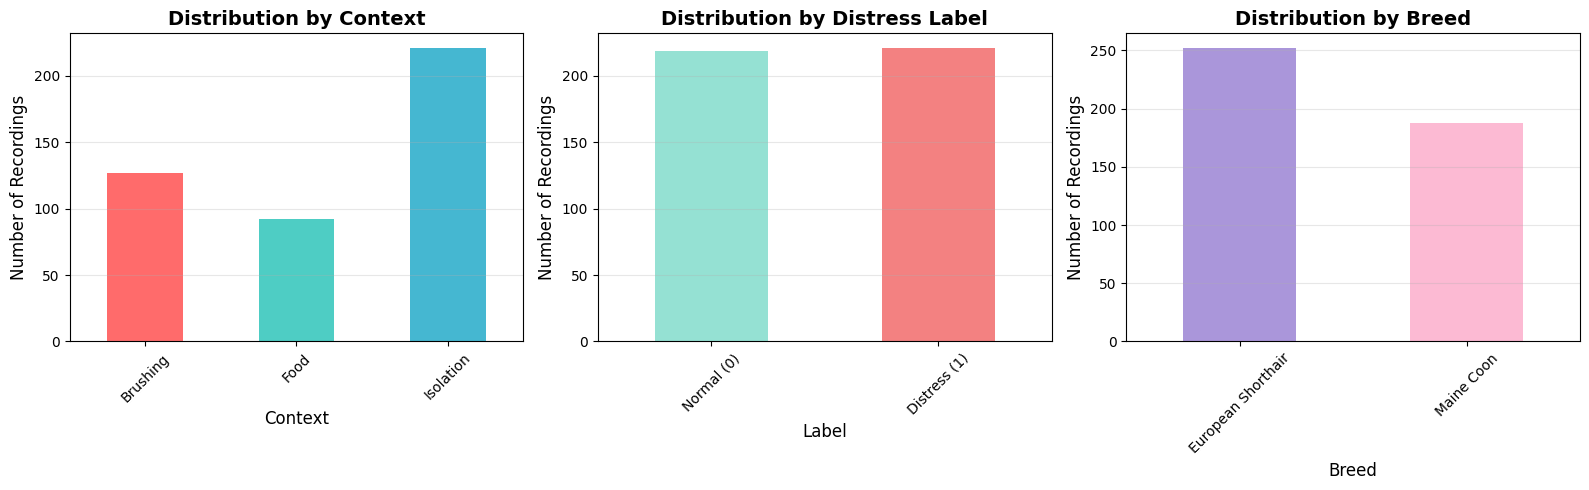

✓ Figure saved to: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/figures/01_dataset_distribution.png


In [5]:
# Visualize context and label distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Context distribution
context_counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Distribution by Context', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Context', fontsize=12)
axes[0].set_ylabel('Number of Recordings', fontsize=12)
axes[0].set_xticklabels(['Brushing', 'Food', 'Isolation'], rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Distress label distribution
label_counts.plot(kind='bar', ax=axes[1], color=['#95E1D3', '#F38181'])
axes[1].set_title('Distribution by Distress Label', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Label', fontsize=12)
axes[1].set_ylabel('Number of Recordings', fontsize=12)
axes[1].set_xticklabels(['Normal (0)', 'Distress (1)'], rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Breed distribution
breed_counts.plot(kind='bar', ax=axes[2], color=['#AA96DA', '#FCBAD3'])
axes[2].set_title('Distribution by Breed', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Breed', fontsize=12)
axes[2].set_ylabel('Number of Recordings', fontsize=12)
axes[2].set_xticklabels(['European Shorthair', 'Maine Coon'], rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {FIGURES_DIR / '01_dataset_distribution.png'}")

Extracting audio properties from all files...
This may take a few minutes...



Loading audio: 100%|██████████| 440/440 [00:21<00:00, 20.02it/s] 


✓ Audio properties extracted for 440 files
Failed to load 0 files

AUDIO PROPERTIES SUMMARY


,duration,sample_rate,max_amplitude,rms_energy
count,440.000000,440.0,440.000000,440.000000
mean,1.831099,8000.0,0.189242,0.030498
std,0.361251,0.0,0.145981,0.028921
min,1.085500,8000.0,0.007355,0.001014
25%,1.635219,8000.0,0.078682,0.009684
50%,1.809562,8000.0,0.146317,0.021860
75%,1.981500,8000.0,0.276054,0.040035
max,4.001500,8000.0,0.592133,0.134100


✓ Full metadata saved to: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/data/metadata_with_audio_props.csv
DURATION ANALYSIS BY CONTEXT


,count,mean,std,min,25%,50%,75%,max
context,,,,,,,,
B,127.0,1.845468,0.491244,1.106625,1.556062,1.806250,1.936688,4.001500
F,92.0,1.641125,0.269968,1.085500,1.428844,1.608437,1.798875,2.302875
I,221.0,1.901927,0.267959,1.221250,1.736125,1.865500,2.027000,2.934625



 ANOVA Test Results:
F-statistic: 18.4244
P-value: 2.0792e-08
✓ Durations are significantly different across contexts (p < 0.05)


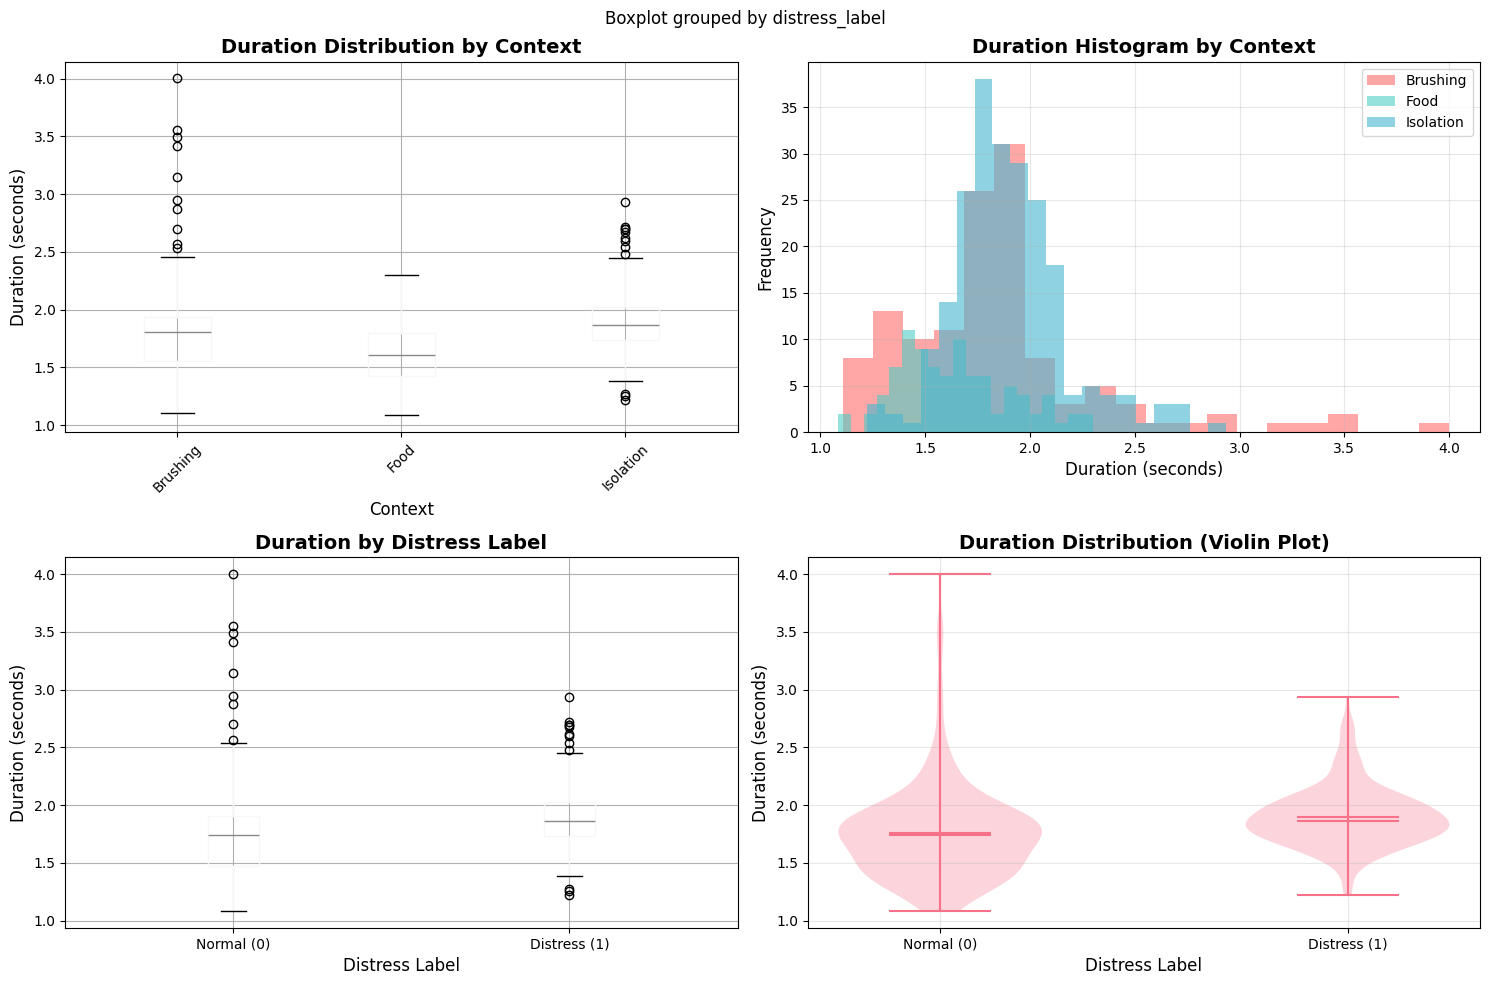

✓ Figure saved to: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/figures/02_duration_analysis.png


In [6]:
def get_audio_properties(file_path):
    """
    Extract basic properties from an audio file.

    Args:
        file_path (str): Path to audio file

    Returns:
        dict: Audio properties (duration, sample_rate, etc.)
    """
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=None)  # sr=None preserves original sample rate

        # Calculate properties
        duration = librosa.get_duration(y=y, sr=sr)
        n_samples = len(y)

        # Amplitude statistics
        max_amplitude = np.max(np.abs(y))
        mean_amplitude = np.mean(np.abs(y))
        rms_energy = np.sqrt(np.mean(y**2))

        return {
            'duration': duration,
            'sample_rate': sr,
            'n_samples': n_samples,
            'max_amplitude': max_amplitude,
            'mean_amplitude': mean_amplitude,
            'rms_energy': rms_energy,
            'is_valid': True
        }
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return {
            'duration': None,
            'sample_rate': None,
            'n_samples': None,
            'max_amplitude': None,
            'mean_amplitude': None,
            'rms_energy': None,
            'is_valid': False,
            'error': str(e)
        }

# %%
# Extract audio properties for all files
print("Extracting audio properties from all files...")
print("This may take a few minutes...\n")

audio_props_list = []

for idx, row in tqdm(df_metadata.iterrows(), total=len(df_metadata), desc="Loading audio"):
    props = get_audio_properties(row['file_path'])
    props['index'] = idx
    audio_props_list.append(props)

# Create DataFrame
df_audio_props = pd.DataFrame(audio_props_list)
df_audio_props.set_index('index', inplace=True)

# Merge with metadata
df_full = pd.concat([df_metadata, df_audio_props], axis=1)

print(f"\n✓ Audio properties extracted for {df_audio_props['is_valid'].sum()} files")
print(f"Failed to load {(~df_audio_props['is_valid']).sum()} files")

# Display summary
print("\n" + "=" * 70)
print("AUDIO PROPERTIES SUMMARY")
print("=" * 70)
display(df_full[['duration', 'sample_rate', 'max_amplitude', 'rms_energy']].describe())

# %%
# Save full dataset with audio properties
full_data_path = DATA_DIR / "metadata_with_audio_props.csv"
df_full.to_csv(full_data_path, index=False)
print(f"✓ Full metadata saved to: {full_data_path}")

# Duration statistics by context
print("=" * 70)
print("DURATION ANALYSIS BY CONTEXT")
print("=" * 70)

duration_stats = df_full.groupby('context')['duration'].describe()
display(duration_stats)

# Statistical test (ANOVA) to check if durations differ significantly
from scipy import stats

brushing_durations = df_full[df_full['context'] == 'B']['duration'].dropna()
food_durations = df_full[df_full['context'] == 'F']['duration'].dropna()
isolation_durations = df_full[df_full['context'] == 'I']['duration'].dropna()

f_stat, p_value = stats.f_oneway(brushing_durations, food_durations, isolation_durations)
print(f"\n ANOVA Test Results:")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("✓ Durations are significantly different across contexts (p < 0.05)")
else:
    print("✗ No significant difference in durations across contexts")

# %%
# Visualize duration distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Box plot by context
df_full.boxplot(column='duration', by='context', ax=axes[0, 0])
axes[0, 0].set_title('Duration Distribution by Context', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Context', fontsize=12)
axes[0, 0].set_ylabel('Duration (seconds)', fontsize=12)
axes[0, 0].set_xticklabels(['Brushing', 'Food', 'Isolation'])
plt.sca(axes[0, 0])
plt.xticks(rotation=45)

# Histogram by context
for context, color in zip(['B', 'F', 'I'], ['#FF6B6B', '#4ECDC4', '#45B7D1']):
    data = df_full[df_full['context'] == context]['duration'].dropna()
    axes[0, 1].hist(data, alpha=0.6, label=context, bins=20, color=color)
axes[0, 1].set_title('Duration Histogram by Context', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Duration (seconds)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].legend(['Brushing', 'Food', 'Isolation'])
axes[0, 1].grid(alpha=0.3)

# Box plot by distress label
df_full.boxplot(column='duration', by='distress_label', ax=axes[1, 0])
axes[1, 0].set_title('Duration by Distress Label', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Distress Label', fontsize=12)
axes[1, 0].set_ylabel('Duration (seconds)', fontsize=12)
axes[1, 0].set_xticklabels(['Normal (0)', 'Distress (1)'])

# Violin plot
parts = axes[1, 1].violinplot(
    [df_full[df_full['distress_label'] == 0]['duration'].dropna(),
     df_full[df_full['distress_label'] == 1]['duration'].dropna()],
    positions=[0, 1],
    showmeans=True,
    showmedians=True
)
axes[1, 1].set_title('Duration Distribution (Violin Plot)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Distress Label', fontsize=12)
axes[1, 1].set_ylabel('Duration (seconds)', fontsize=12)
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Normal (0)', 'Distress (1)'])
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_duration_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {FIGURES_DIR / '02_duration_analysis.png'}")

SAMPLE RATE ANALYSIS

Sample Rates Found:
  8000 Hz: 440 files (100.0%)

✓ All files have consistent sample rate: 8000 Hz
Selected representative examples:
  B (Brushing): B_NUL01_MC_MI_SIM01_301.wav - Duration: 1.81s
  F (Food waiting): F_MAG01_EU_FN_FED01_202.wav - Duration: 1.62s
  I (Isolation): I_DAK01_MC_FN_SIM01_103.wav - Duration: 1.87s


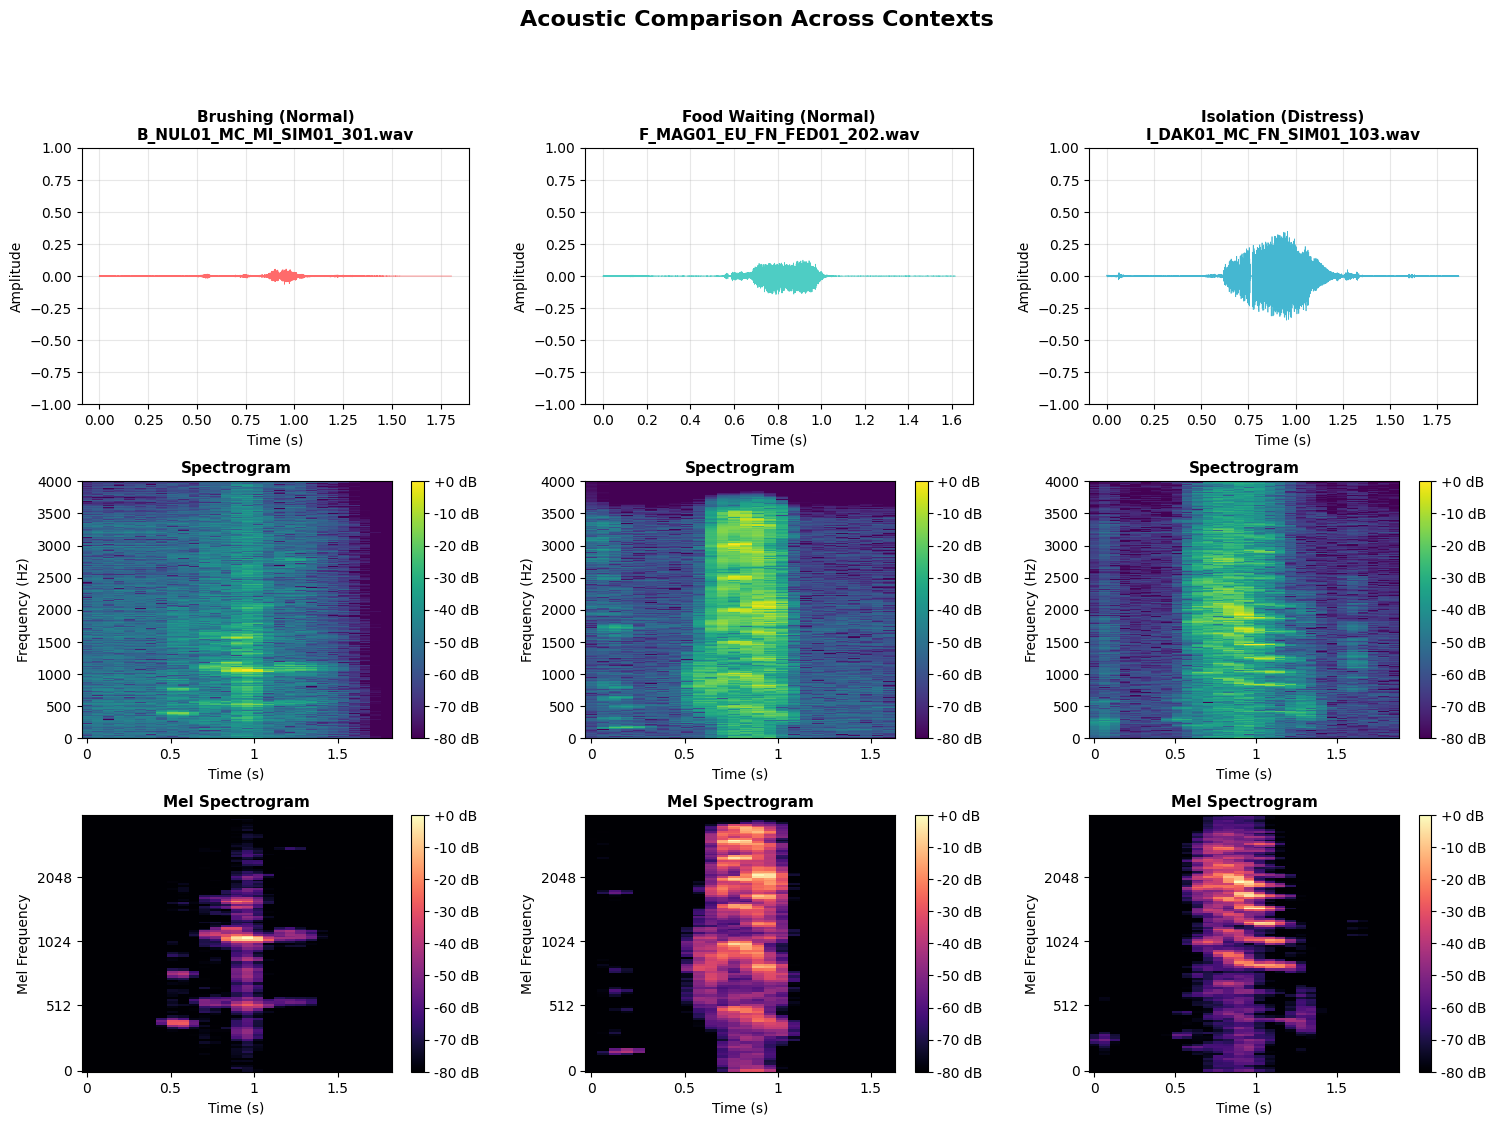

✓ Figure saved to: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/figures/03_acoustic_comparison.png


In [7]:
# Check sample rate consistency
print("=" * 70)
print("SAMPLE RATE ANALYSIS")
print("=" * 70)

sample_rates = df_full['sample_rate'].value_counts()
print(f"\nSample Rates Found:")
for sr, count in sample_rates.items():
    print(f"  {sr} Hz: {count} files ({count/len(df_full)*100:.1f}%)")

# Check if all files have the same sample rate
if len(sample_rates) == 1:
    print(f"\n✓ All files have consistent sample rate: {sample_rates.index[0]} Hz")
    TARGET_SR = int(sample_rates.index[0])
else:
    print(f"\n⚠️  Multiple sample rates detected. Will need to resample.")
    TARGET_SR = 22050  # Standard for audio ML
    print(f"   Target sample rate for preprocessing: {TARGET_SR} Hz")

# Select one example from each context
examples = {}
for context in ['B', 'F', 'I']:
    # Get a medium-duration example (close to median)
    context_data = df_full[df_full['context'] == context]
    median_duration = context_data['duration'].median()

    # Find file closest to median duration
    idx = (context_data['duration'] - median_duration).abs().idxmin()
    examples[context] = df_full.loc[idx]

print("Selected representative examples:")
for ctx, row in examples.items():
    ctx_name = {'B': 'Brushing', 'F': 'Food waiting', 'I': 'Isolation'}[ctx]
    print(f"  {ctx} ({ctx_name}): {row['filename']} - Duration: {row['duration']:.2f}s")

# %%
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

context_names = {'B': 'Brushing (Normal)', 'F': 'Food Waiting (Normal)', 'I': 'Isolation (Distress)'}
colors = {'B': '#FF6B6B', 'F': '#4ECDC4', 'I': '#45B7D1'}

for col_idx, (context, row) in enumerate(examples.items()):
    # Load audio
    y, sr = librosa.load(row['file_path'], sr=None)

    # Create time array
    time = np.linspace(0, len(y)/sr, len(y))

    # Row 1: Waveform
    ax1 = fig.add_subplot(gs[0, col_idx])
    ax1.plot(time, y, color=colors[context], linewidth=0.5)
    ax1.set_title(f'{context_names[context]}\n{row["filename"]}',
                  fontsize=11, fontweight='bold')
    ax1.set_xlabel('Time (s)', fontsize=10)
    ax1.set_ylabel('Amplitude', fontsize=10)
    ax1.grid(alpha=0.3)
    ax1.set_ylim(-1, 1)

    # Row 2: Spectrogram
    ax2 = fig.add_subplot(gs[1, col_idx])
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax2, cmap='viridis')
    ax2.set_title('Spectrogram', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Time (s)', fontsize=10)
    ax2.set_ylabel('Frequency (Hz)', fontsize=10)
    ax2.set_ylim(0, 4000)  # Focus on relevant frequency range
    plt.colorbar(img, ax=ax2, format='%+2.0f dB')

    # Row 3: Mel Spectrogram
    ax3 = fig.add_subplot(gs[2, col_idx])
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=ax3, cmap='magma')
    ax3.set_title('Mel Spectrogram', fontsize=11, fontweight='bold')
    ax3.set_xlabel('Time (s)', fontsize=10)
    ax3.set_ylabel('Mel Frequency', fontsize=10)
    plt.colorbar(img, ax=ax3, format='%+2.0f dB')

fig.suptitle('Acoustic Comparison Across Contexts', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(FIGURES_DIR / '03_acoustic_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {FIGURES_DIR / '03_acoustic_comparison.png'}")

In [8]:
print("=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

# Check for issues
issues = []

# 1. Very short recordings (< 0.2 seconds)
short_files = df_full[df_full['duration'] < 0.2]
if len(short_files) > 0:
    print(f"\n  Found {len(short_files)} very short recordings (< 0.2s):")
    display(short_files[['filename', 'context', 'duration']])
    issues.extend(short_files.index.tolist())

# 2. Very long recordings (> 10 seconds)
long_files = df_full[df_full['duration'] > 10]
if len(long_files) > 0:
    print(f"\n  Found {len(long_files)} very long recordings (> 10s):")
    display(long_files[['filename', 'context', 'duration']])
    issues.extend(long_files.index.tolist())

# 3. Files with very low energy (possibly silent)
low_energy = df_full[df_full['rms_energy'] < 0.001]
if len(low_energy) > 0:
    print(f"\n  Found {len(low_energy)} low energy recordings (RMS < 0.001):")
    display(low_energy[['filename', 'context', 'rms_energy']])
    issues.extend(low_energy.index.tolist())

# 4. Files that failed to load
invalid_files = df_full[~df_full['is_valid']]
if len(invalid_files) > 0:
    print(f"\n Found {len(invalid_files)} files that failed to load:")
    display(invalid_files[['filename', 'error']])
    issues.extend(invalid_files.index.tolist())

# Remove duplicates from issues list
issues = list(set(issues))

if len(issues) == 0:
    print("\n✓ No data quality issues detected!")
else:
    print(f"\n  Total files with potential issues: {len(issues)}")
    print(f"   Percentage of dataset: {len(issues)/len(df_full)*100:.2f}%")

# Mark problematic files in dataframe
df_full['has_quality_issue'] = df_full.index.isin(issues)

# Save updated dataset
df_full.to_csv(DATA_DIR / "metadata_with_quality_check.csv", index=False)
print(f"\n✓ Updated metadata saved with quality flags")

DATA QUALITY CHECK

✓ No data quality issues detected!

✓ Updated metadata saved with quality flags


CAT-LEVEL ANALYSIS

Recordings per cat per context:


context,B,F,I
cat_id,,,
ANI01,6,0,4
BAC01,6,12,7
BLE01,0,3,45
BRA01,7,2,10
BRI01,7,8,0
CAN01,26,2,26
CLE01,0,0,20
DAK01,4,4,32
IND01,11,10,0



Summary:
  Average recordings per cat: 21.0
  Min recordings for a cat: 5
  Max recordings for a cat: 54

  Cats with missing contexts:


context,B,F,I
cat_id,,,
ANI01,6,0,4
BLE01,0,3,45
BRI01,7,8,0
CLE01,0,0,20
IND01,11,10,0
JJX01,7,0,0
LEO01,0,5,0
MEG01,0,4,10
NIG01,4,0,1


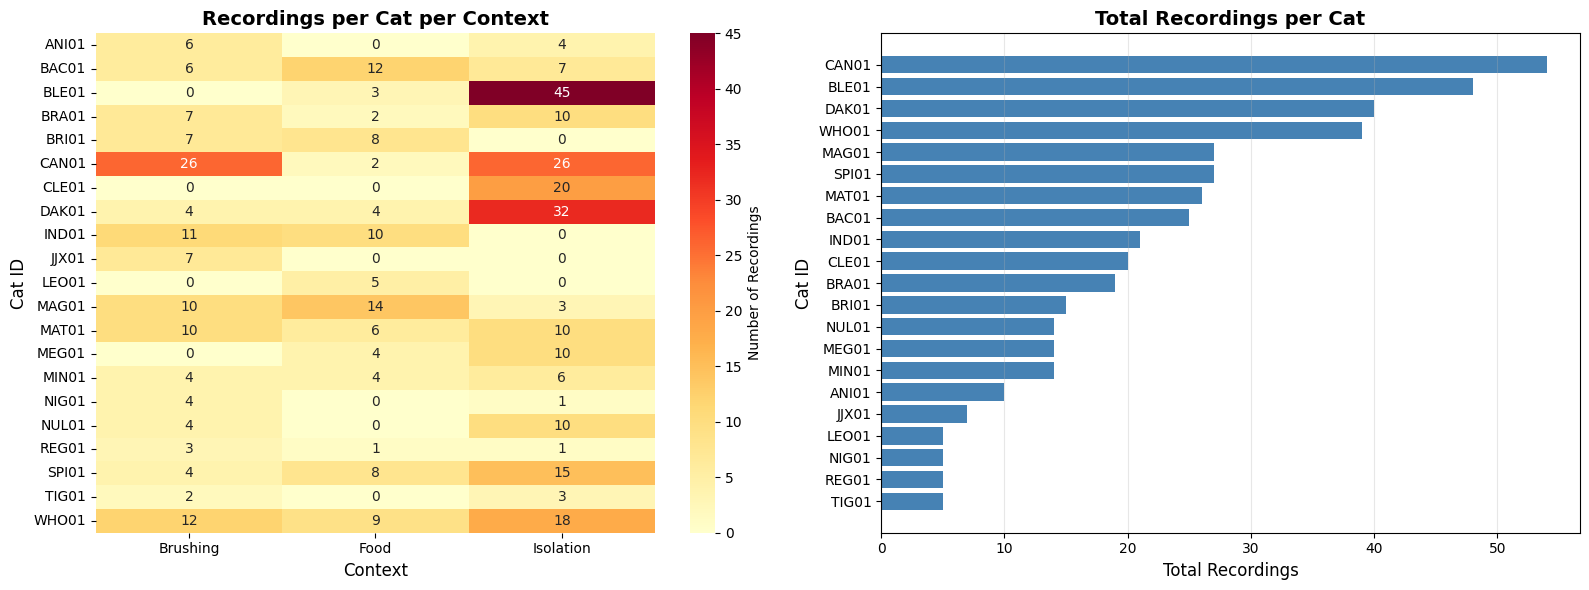

✓ Figure saved to: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/figures/04_cat_level_analysis.png


In [9]:
print("=" * 70)
print("CAT-LEVEL ANALYSIS")
print("=" * 70)

# Recordings per cat
cats_per_context = df_full.pivot_table(
    index='cat_id',
    columns='context',
    values='filename',
    aggfunc='count',
    fill_value=0
)

print(f"\nRecordings per cat per context:")
display(cats_per_context)

# Summary statistics
print(f"\nSummary:")
print(f"  Average recordings per cat: {len(df_full) / df_full['cat_id'].nunique():.1f}")
print(f"  Min recordings for a cat: {cats_per_context.sum(axis=1).min()}")
print(f"  Max recordings for a cat: {cats_per_context.sum(axis=1).max()}")

# Check for missing contexts
cats_missing_contexts = cats_per_context[(cats_per_context == 0).any(axis=1)]
if len(cats_missing_contexts) > 0:
    print(f"\n  Cats with missing contexts:")
    display(cats_missing_contexts)
else:
    print(f"\n✓ All cats have recordings in all contexts")

# %%
# Visualize recordings per cat
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of recordings per cat per context
sns.heatmap(cats_per_context, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': 'Number of Recordings'})
axes[0].set_title('Recordings per Cat per Context', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Context', fontsize=12)
axes[0].set_ylabel('Cat ID', fontsize=12)
axes[0].set_xticklabels(['Brushing', 'Food', 'Isolation'])

# Total recordings per cat
total_per_cat = cats_per_context.sum(axis=1).sort_values(ascending=False)
axes[1].barh(range(len(total_per_cat)), total_per_cat.values, color='steelblue')
axes[1].set_yticks(range(len(total_per_cat)))
axes[1].set_yticklabels(total_per_cat.index)
axes[1].set_xlabel('Total Recordings', fontsize=12)
axes[1].set_ylabel('Cat ID', fontsize=12)
axes[1].set_title('Total Recordings per Cat', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_cat_level_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {FIGURES_DIR / '04_cat_level_analysis.png'}")